In [1]:
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import concatenate
from tensorflow.keras.layers import  Conv2D, MaxPooling2D

# Just dual input

In [9]:
def createDualInputModel():
    #left branch
    Lin = Input(shape=(16,16,3))
    Lx = Conv2D(32,(3,3),
                padding='same',
                activation='relu')(Lin)
    Lx = MaxPooling2D(pool_size=(2,2))(Lx)

    #right branch
    Rin = Input(shape=(8,8,3))
    Rx = Conv2D(32,(3,3),
                padding='same',
                activation='relu')(Rin)

    x = concatenate([Lx,Rx],axis=-1)
    x = Conv2D(64,(3,3),
                padding='same',
                activation='relu')(x)
    x = MaxPooling2D(pool_size=(2,2))(x)
    
    x = Flatten()(x)
    x = Dense(256,activation='relu')(x)
    out = Dense(10,activation='softmax')(x)

    model = Model(inputs=[Lin,Rin],outputs=out)
    model.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
    return model

In [10]:
modelDual = createDualInputModel()
modelDual.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 16, 16, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 8, 8, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 32)  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 32)  │        896 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 64)  │          0 │ max_pooling2d_4[… │
│ (Concatenate)       │                   │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 4, 4, 64)  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1024)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    262,400 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │      2,570 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 303,690 (1.16 MB)

 Trainable params: 303,690 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.utils import plot_model
plot_model(modelDual,
            to_file='Dual_model.pdf',
            show_shapes=True,
            show_layer_names=False,
            rankdir='TB')

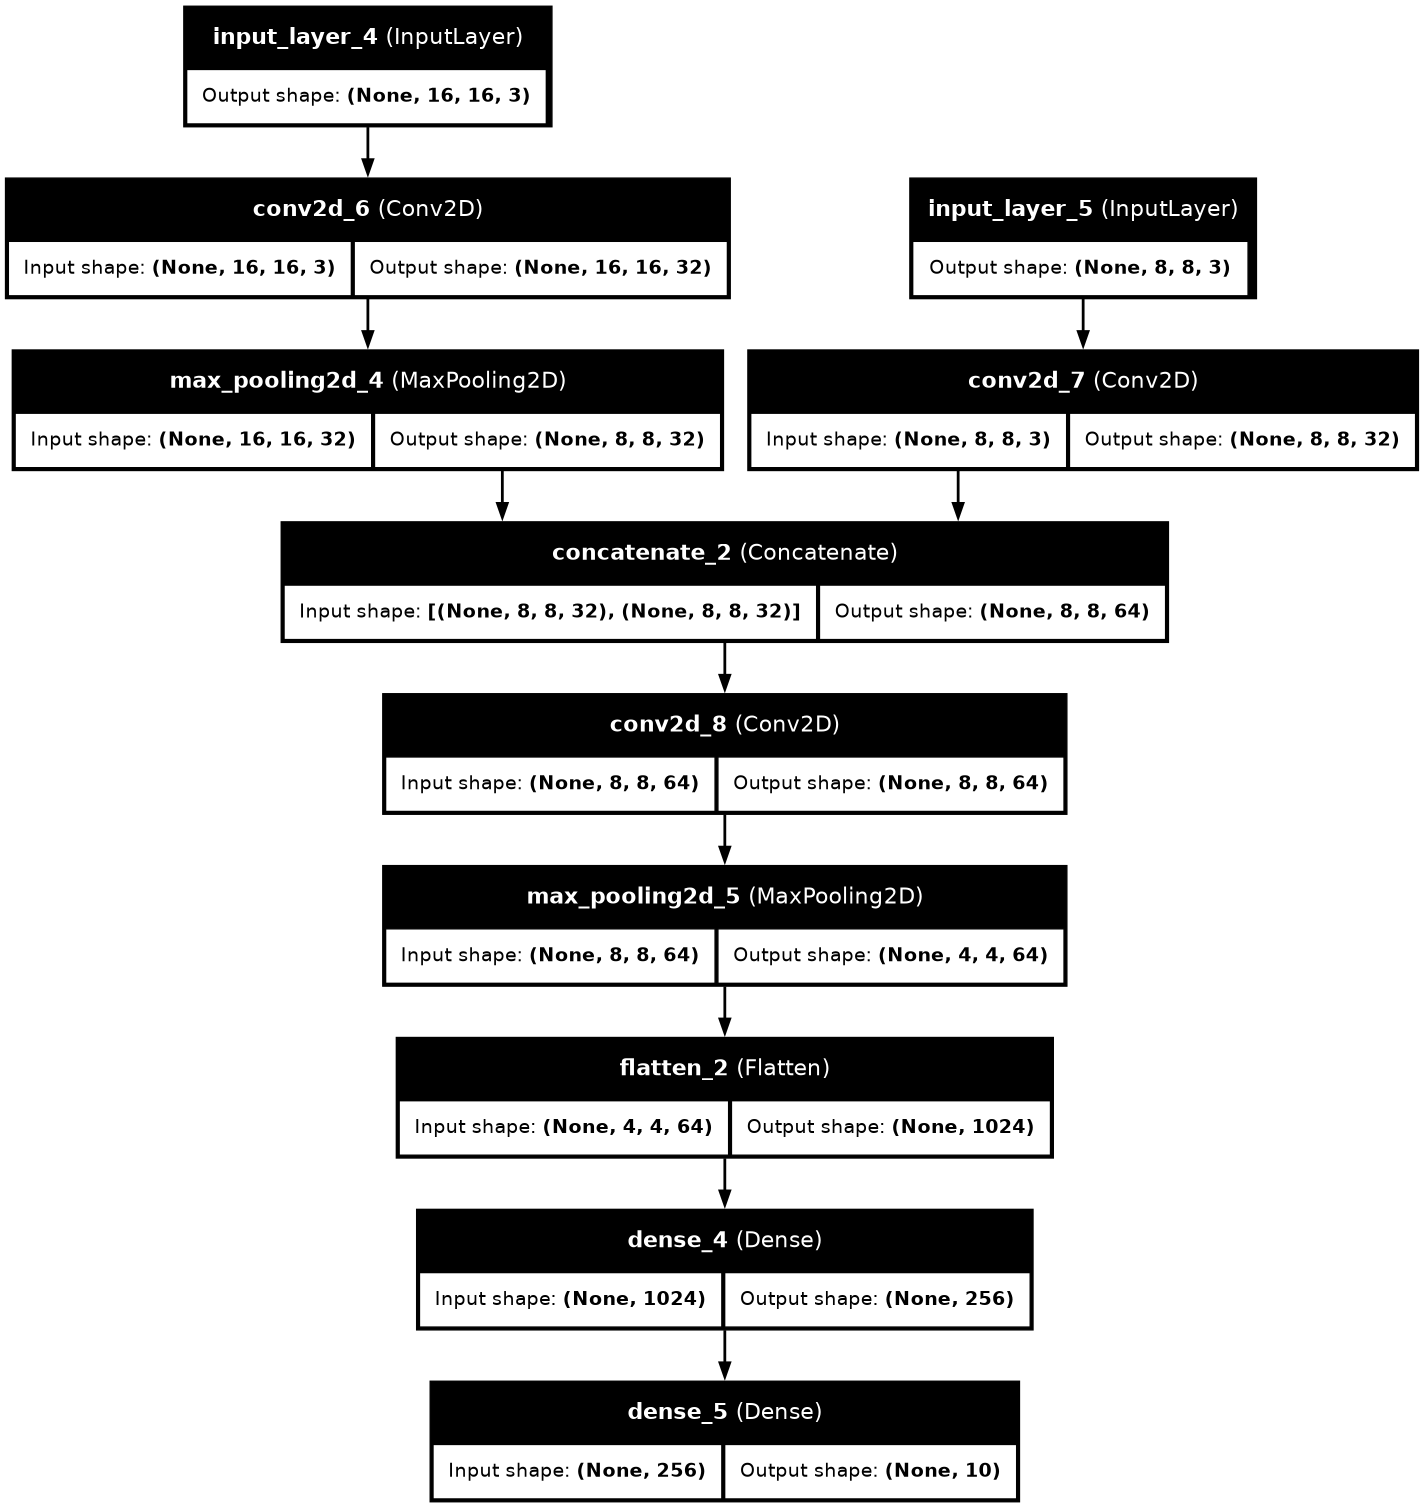

In [11]:
plot_model(modelDual,
            dpi=100,
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB')

# Shared layers model
The same filter weights are applied to both sides (that’s the “shared” concept).\
A convolution is basically “sliding a small pattern (filter/kernel) across the image and computing how well it matches at each location. Detects local patterns\
If input = size H×W×Cin ; filter = k×k×Cin , stride = 1, padding = ‘valid’, output size is:\
(H−k+1,W−k+1,Cout)

and if you add padding = ‘same’, the output keeps H×W spatial size.\
Cin = input channels/input depth
Cout = output channels/output depth (number of filters) -- i.e. hwo many distinct feature maps will it learn


In [13]:
def createSharedModel():
    shared = Conv2D(5,(3,3),activation='relu',name='SharedLyr') #This applies 5 filters of size 3x3 to its input; this has no padding (default='valid'), hence it will reduce it's input spatial dimension by 3 and add 1 for bias i.e. one bias weight per filter

    #left branch
    Lin = Input(shape=(16,16,3),name='LeftIn') #→ a 16 × 16 pixel RGB image (3 channels).
    Lx = Conv2D(32,(3,3), #apply 32 filters of size 3x3
                padding='same', #apply enough padding to keep spatial dimensions the same (16x16)
                activation='relu')(Lin) # ==> output 16x16x32 i.e. 32 feature maps instead of 3 colour channels; we expect each filter to have detected a different pattern (edge, texture, etc)
    Lx = MaxPooling2D(pool_size=(2,2))(Lx) #downsample by 2 in each spatial dimension, keep all 32 channel, reduce 16x16 to 8x8
    Lx = shared(Lx) #the shared layer now “learns” that its expected input has 32 channels; output = (8 − 3 + 1, 8 − 3 + 1, 5) = (6, 6, 5) i.e. 5 feature maps of 6x6
    Lx = Flatten(name='LeftOut')(Lx) #summarizes left branch’s learned representation

    #right branch
    Rin = Input(shape=(8,8,3),name='RightIn') #→ an 8 × 8 pixel RGB image.
    Rx = Conv2D(32,(3,3), #32 filters
                padding='same', #keep spatial dimensions the same (8x8)
                activation='relu')(Rin)
    Rx = shared(Rx) #output = (8 − 3 + 1, 8 − 3 + 1, 5) = (6, 6, 5) i.e. 5 feature maps of 6x6
    Rx = Flatten(name='RightOut')(Rx) #summarizes right branch’s learned representation

    model = Model(inputs=[Lin,Rin],outputs=[Lx,Rx])
    model.compile(loss={'LeftOut':'categorical_crossentropy',
                       'RightOut':'mean_squared_error'},
                optimizer='rmsprop',
                metrics=['accuracy'])
    return model

In [14]:
modelShared = createSharedModel()
modelShared.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ LeftIn (InputLayer) │ (None, 16, 16, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │        896 │ LeftIn[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RightIn             │ (None, 8, 8, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 32)  │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 32)  │        896 │ RightIn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SharedLyr (Conv2D)  │ (None, 6, 6, 5)   │      1,445 │ max_pooling2d_7[… │
│                     │                   │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LeftOut (Flatten)   │ (None, 180)       │          0 │ SharedLyr[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RightOut (Flatten)  │ (None, 180)       │          0 │ SharedLyr[1][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237 (12.64 KB)

 Trainable params: 3,237 (12.64 KB)

 Non-trainable params: 0 (0.00 B)

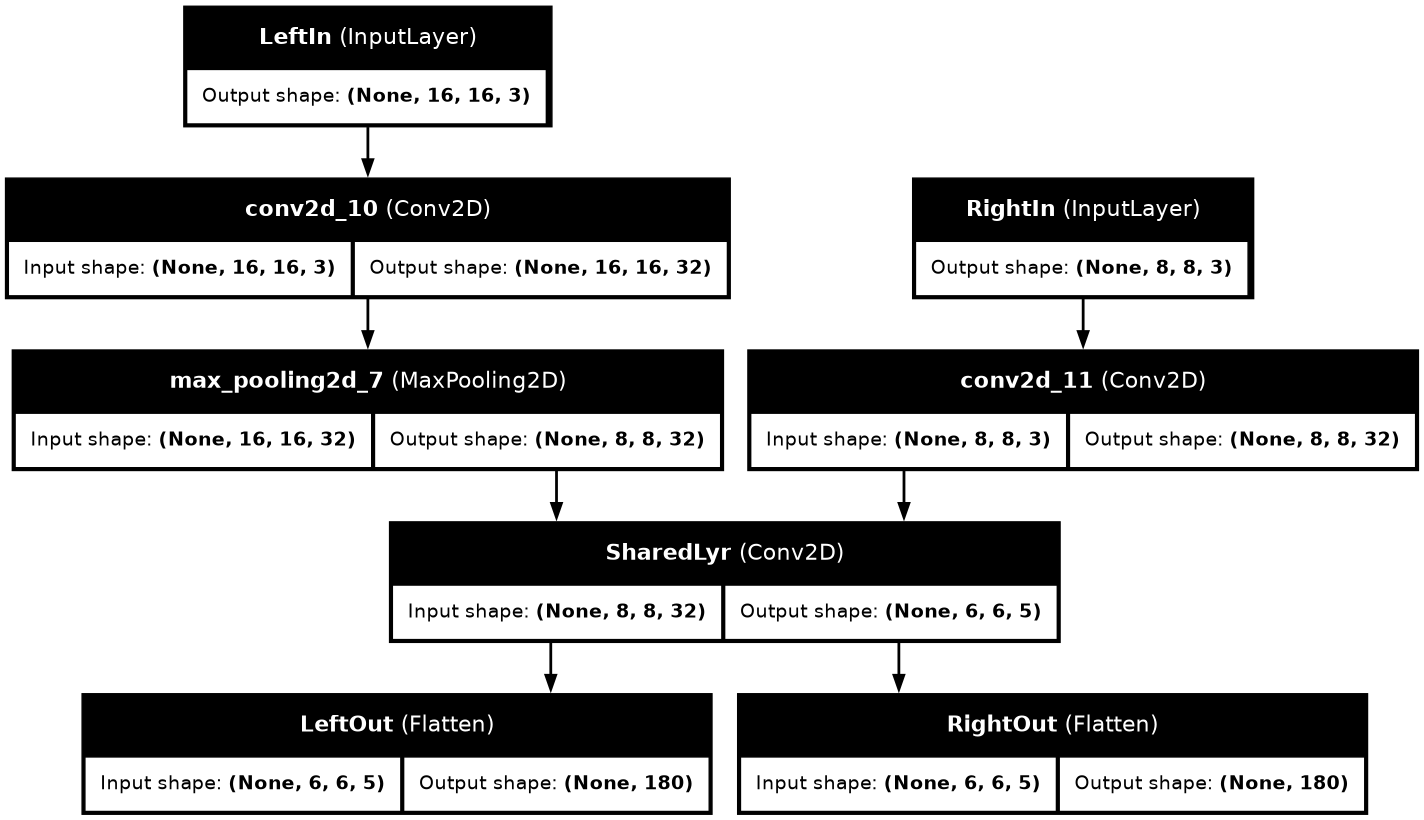

In [15]:
plot_model(modelShared,
            dpi=100,
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB')

# DualTw model...
Dual inputs, shared layers, combined output

In [22]:
def createDualTwModel():


    #left branch - 1
    Lin = Input(shape=(32,32,3),name='LeftIn')
    Lx = Conv2D(16,(3,3),
                padding='same',
                activation='relu')(Lin)
    Lx = Conv2D(16,(3,3),
                padding='same',
                activation='relu')(Lx)
    Lx = MaxPooling2D(pool_size=(2,2))(Lx)
    #right branch - 1
    Rin = Input(shape=(16,16,3),name='RightIn')
    Rx = Conv2D(16,(3,3),
                padding='same',
                activation='relu')(Rin)

    #shared layer - 1
    shared = Conv2D(32,(3,3),activation='relu',padding='same',name='SharedLyr1')
    Lx = shared(Lx)
    Rx = shared(Rx)

    #left branch - 2
    Lx = MaxPooling2D(pool_size=(2,2))(Lx)
    #right branch - 2
    Rx = MaxPooling2D(pool_size=(2,2))(Rx)

    #shared layer - 2
    shared2 = Conv2D(48,(3,3),activation='relu',padding='same',name='SharedLyr2')
    Lx = shared2(Lx)
    Rx = shared2(Rx)

    #left branch - 3
    Lx = MaxPooling2D(pool_size=(2,2))(Lx)
    #right branch - 3
    Rx = MaxPooling2D(pool_size=(2,2))(Rx)

    #shared layer - 3
    shared3 = Conv2D(64,(3,3),activation='relu',padding='same',name='SharedLyr3')
    Lx = shared3(Lx)
    Rx = shared3(Rx)

    #left branch - 4
    Lx = MaxPooling2D(pool_size=(2,2))(Lx)
    #right branch - 4
    Rx = MaxPooling2D(pool_size=(2,2))(Rx)

    #concat layers
    x = concatenate([Lx,Rx],axis=-1,name='ConcatLayer')
    x = Flatten(name='FlattenedLayer')(x)

    x = Dense(128,activation='relu',name='HiddenDenseLayer')(x)
    out = Dense(3,activation='softmax',name='OutputDenseLayer')(x)

    model = Model(inputs=[Lin,Rin],outputs=out)
    model.compile(loss={'LeftOut':'categorical_crossentropy',
'                       RightOut':'mean_squared_error'},
                optimizer='rmsprop',
                metrics=['accuracy'])
    return model

In [23]:
modelDualTw = createDualTwModel()
modelDualTw.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ LeftIn (InputLayer) │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │        448 │ LeftIn[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      2,320 │ conv2d_24[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RightIn             │ (None, 16, 16, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 16, 16,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │        448 │ RightIn[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SharedLyr1 (Conv2D) │ (None, 16, 16,    │      4,640 │ max_pooling2d_31… │
│                     │ 32)               │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 8, 8, 32)  │          0 │ SharedLyr1[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 8, 8, 32)  │          0 │ SharedLyr1[1][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SharedLyr2 (Conv2D) │ (None, 8, 8, 48)  │     13,872 │ max_pooling2d_32… │
│                     │                   │            │ max_pooling2d_33… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_34    │ (None, 4, 4, 48)  │          0 │ SharedLyr2[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_35    │ (None, 4, 4, 48)  │          0 │ SharedLyr2[1][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SharedLyr3 (Conv2D) │ (None, 4, 4, 64)  │     27,712 │ max_pooling2d_34… │
│                     │                   │            │ max_pooling2d_35… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 2, 2, 64)  │          0 │ SharedLyr3[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_37    │ (None, 2, 2, 64)  │          0 │ SharedLyr3[1][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ConcatLayer         │ (None, 2, 2, 128) │          0 │ max_pooling2d_36… │
│ (Concatenate)       │                   │            │ max_pooling2d_37… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FlattenedLayer      │ (None, 512)       │          0 │ ConcatLayer[0][0] │
│ (Flatten)           │                   │            │                 

 Total params: 115,491 (451.14 KB)

 Trainable params: 115,491 (451.14 KB)

 Non-trainable params: 0 (0.00 B)

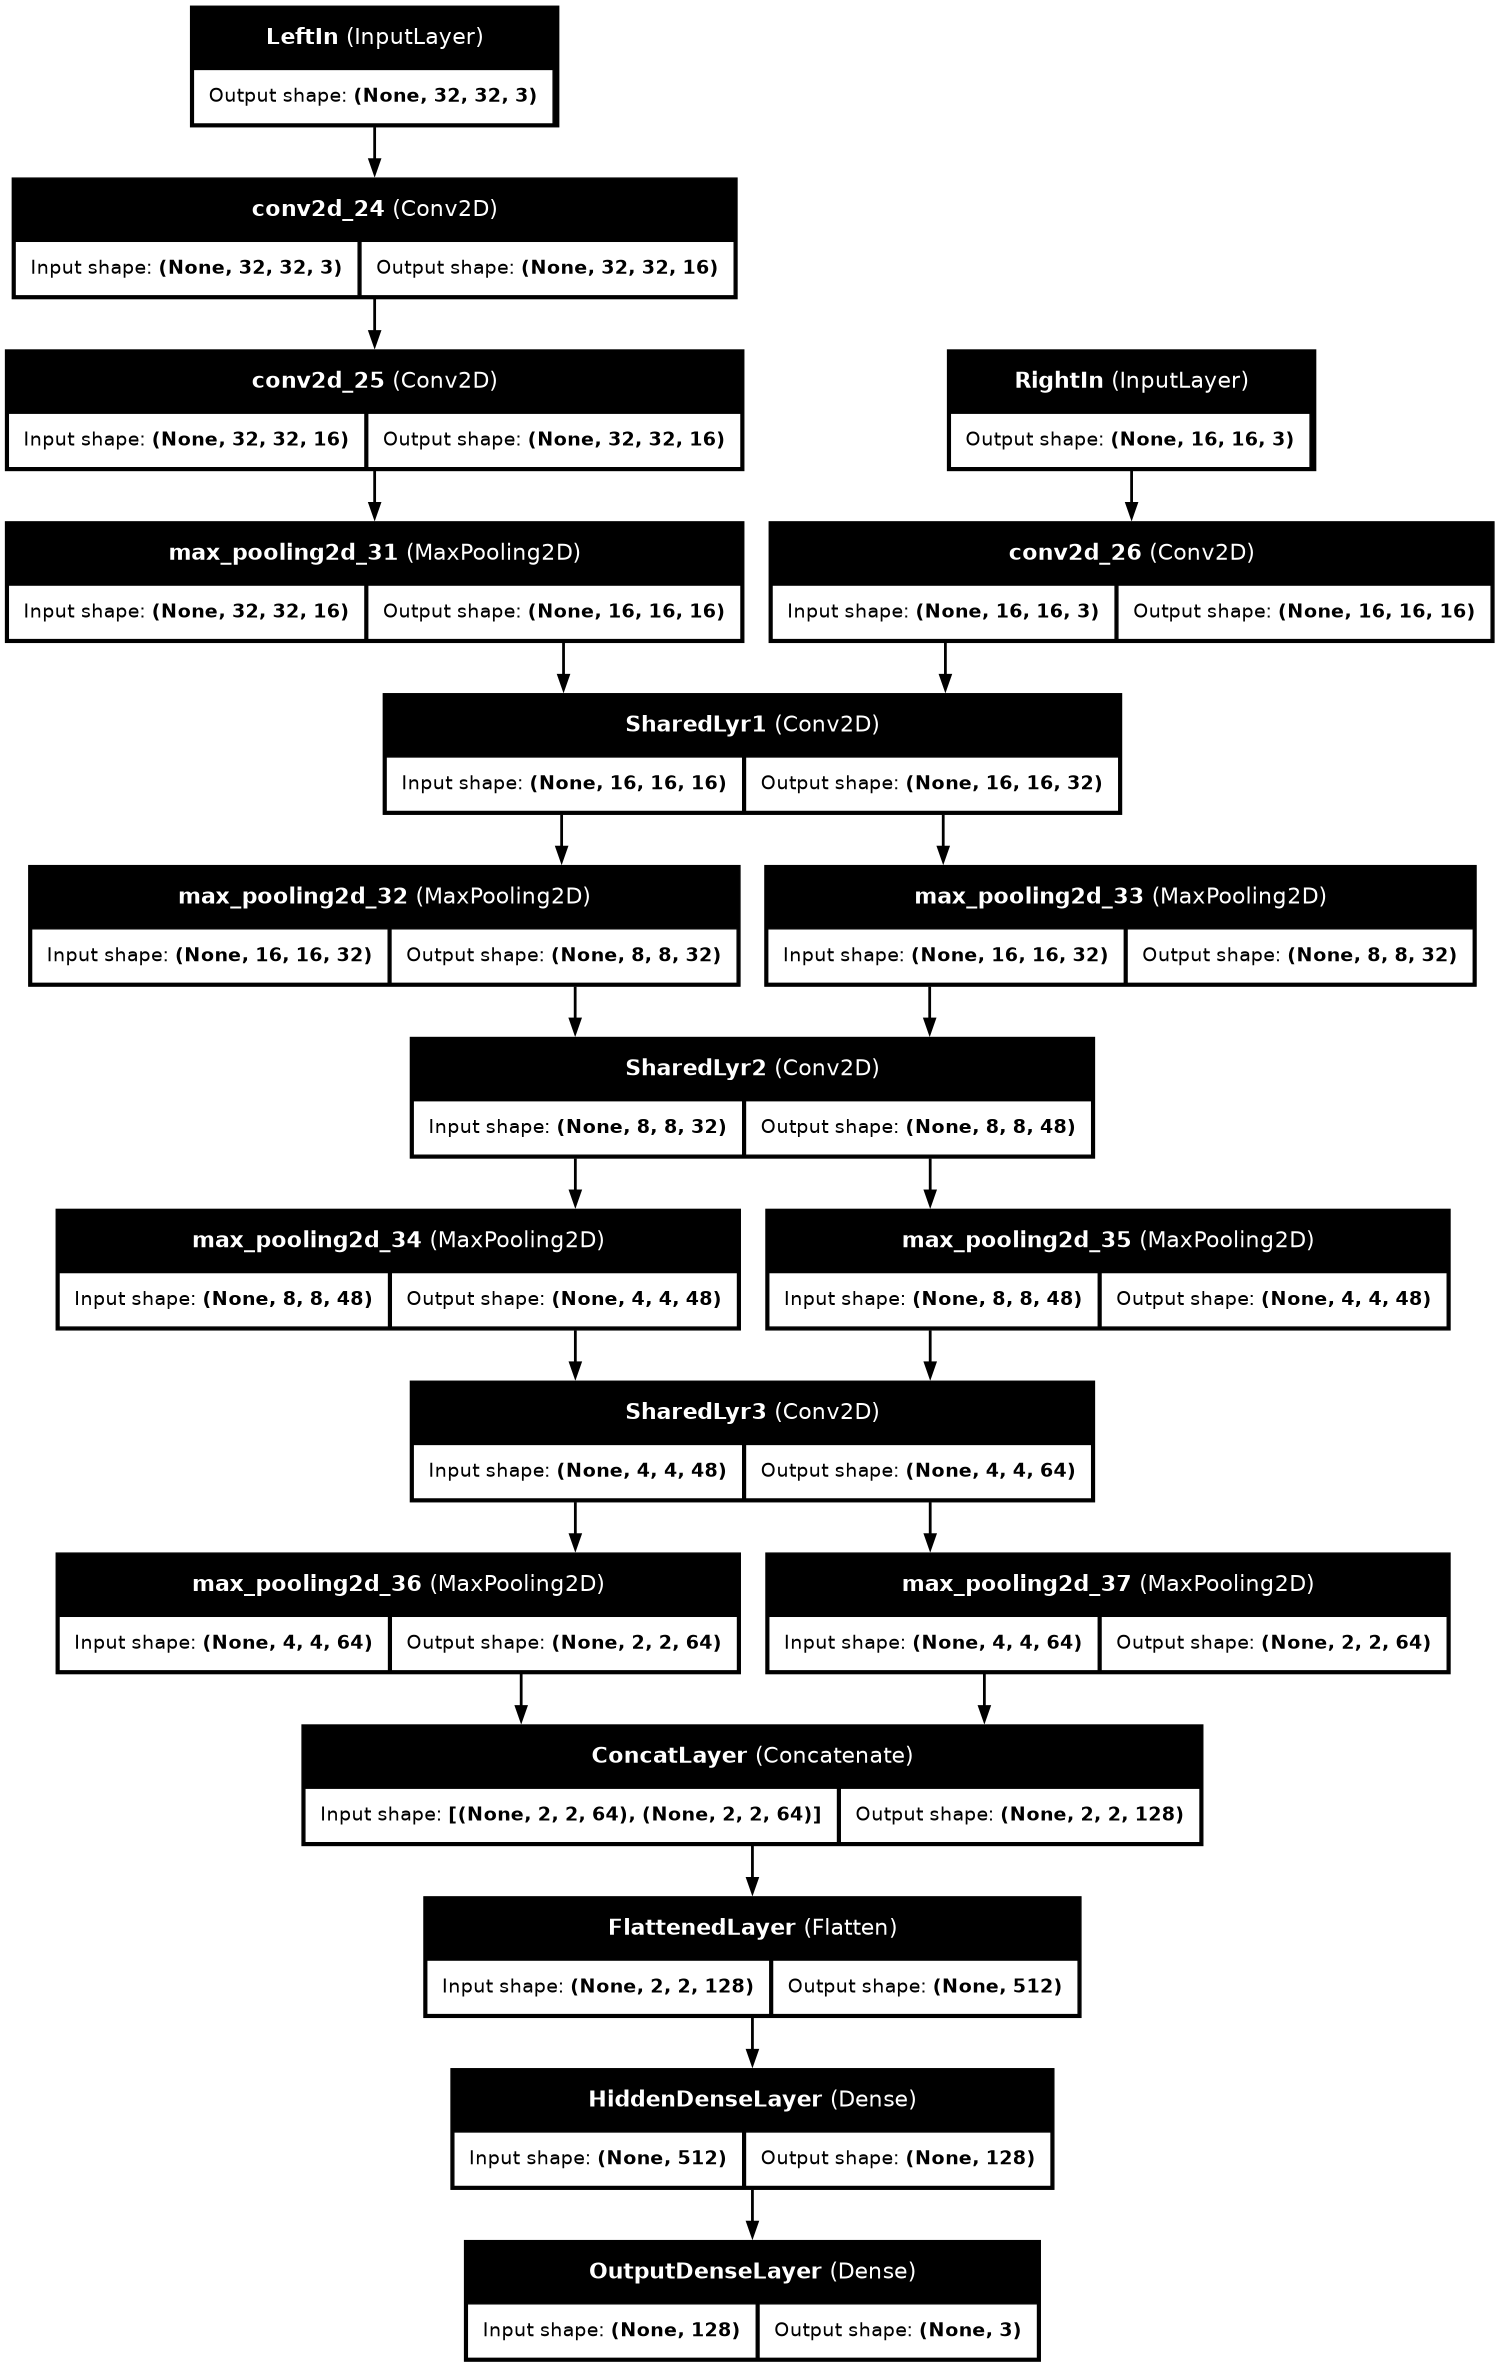

In [25]:
plot_model(modelDualTw,
            dpi=100,
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB')